# Hard coal + CCS NPV simulation

Run the hard coal+CCS electricity Monte Carlo simulation and visualize the resulting NPV distribution.

The summary also reports how many simulations have non-negative NPV (NPV >= 0) and how many have negative NPV.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_results,
)

from npv_summary import summarize_metric_signs


In [2]:
TECHNOLOGY = 'hard_coal_ccs'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

results_by_technology = simulate_electricity_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,lifetime_years,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,...,initial_capex_eur,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_mwh,levelized_net_margin_eur_per_mwh
0,0,hard_coal_ccs,1000000.0,4100.0,30.0,243.902439,243902.439024,5072.887962,85.944756,10.760253,...,1.237290e+09,94070000.0,2.096214e+07,1.076025e+07,3.612942e+07,6.473351e+06,1.974484e+07,-1.015007e+09,1.125778e+07,-90.160430
1,1,hard_coal_ccs,1000000.0,4100.0,30.0,243.902439,243902.439024,5123.516063,79.865937,9.537015,...,1.249638e+09,94070000.0,1.947950e+07,9.537015e+06,3.897235e+07,6.445161e+06,1.963598e+07,-1.028580e+09,1.125778e+07,-91.366164
2,2,hard_coal_ccs,1000000.0,4100.0,30.0,243.902439,243902.439024,3322.101537,84.402473,10.575742,...,8.102687e+08,94070000.0,2.058597e+07,1.057574e+07,4.245323e+07,3.423195e+06,1.703186e+07,-6.185276e+08,1.125778e+07,-54.942221
3,3,hard_coal_ccs,1000000.0,4100.0,30.0,243.902439,243902.439024,3034.867418,79.487777,13.192068,...,7.402116e+08,94070000.0,1.938726e+07,1.319207e+07,3.808651e+07,5.226359e+06,1.817780e+07,-5.355698e+08,1.125778e+07,-47.573292
4,4,hard_coal_ccs,1000000.0,4100.0,30.0,243.902439,243902.439024,3678.059405,100.622855,12.319069,...,8.970877e+08,94070000.0,2.454216e+07,1.231907e+07,4.471638e+07,5.903242e+06,6.589152e+06,-8.229084e+08,1.125778e+07,-73.096843


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
levelized_net_margin_eur_per_mwh = results["levelized_net_margin_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        levelized_net_margin_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "Levelized net margin EUR/MWh"
        ),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,Levelized net margin EUR/MWh
count,100000.000000,100000.000000
mean,-784.341489,-69.671041
std,174.766654,15.524073
min,-1412.678609,-125.484615
5%,-1069.378198,-94.990121
50%,-783.971565,-69.638182
95%,-503.806758,-44.751861
max,-307.596134,-27.322975


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),0,0.0
1,Negative (NPV < 0),100000,1.0


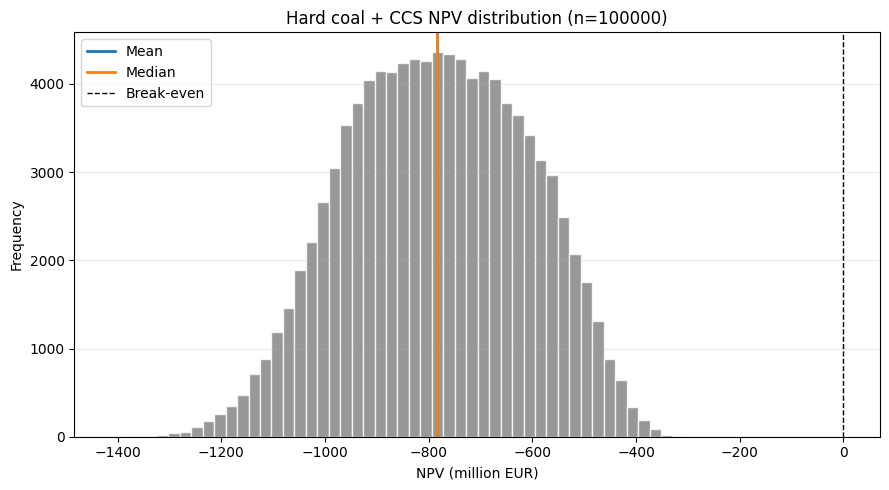

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal + CCS NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

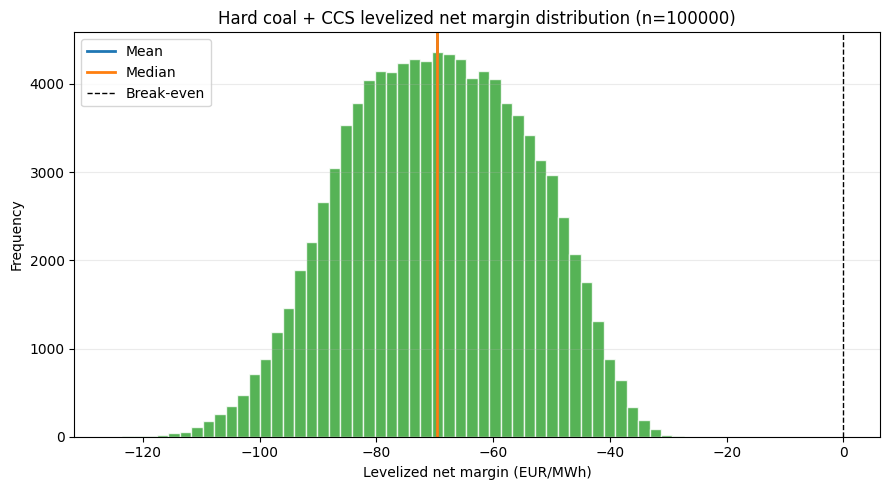

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    levelized_net_margin_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    levelized_net_margin_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    levelized_net_margin_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal + CCS levelized net margin distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("Levelized net margin (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        21.089379
annual_variable_opex_eur     11.270694
annual_fuel_cost_eur         38.245316
annual_emissions_cost_eur     4.800024
annual_net_cash_flow_eur     18.664587
Name: Mean annual value, million EUR, dtype: float64